Step 1 – Load Libraries

In [1]:
# Check GPU name and GPU RAM in Google Colab

import subprocess

def check_gpu():
    try:
        result = subprocess.check_output(
            [
                "nvidia-smi",
                "--query-gpu=name,memory.total,memory.used,memory.free",
                "--format=csv,noheader,nounits"
            ],
            encoding="utf-8"
        )

        gpu_info = result.strip().split("\n")

        for i, gpu in enumerate(gpu_info):
            name, total, used, free = gpu.split(",")

            total = int(total.strip())
            used = int(used.strip())
            free = int(free.strip())

            print(f"GPU {i + 1}")
            print(f"Name       : {name.strip()}")
            print(f"Total RAM  : {total} MB / {total / 1024:.2f} GB")
            print(f"Used RAM   : {used} MB / {used / 1024:.2f} GB")
            print(f"Free RAM   : {free} MB / {free / 1024:.2f} GB")
            print("-" * 40)

    except Exception as e:
        print("No GPU detected or nvidia-smi is not available.")
        print("Error:", e)

check_gpu()

GPU 1
Name       : NVIDIA A100-SXM4-80GB
Total RAM  : 81920 MB / 80.00 GB
Used RAM   : 0 MB / 0.00 GB
Free RAM   : 81153 MB / 79.25 GB
----------------------------------------


In [2]:
!pip install mne PyWavelets scikit-learn seaborn tensorflow pandas tqdm

In [3]:
# %% Step 1 - Load libraries

# Install these once if needed:
# pip install mne
# pip install PyWavelets
# pip install scikit-learn
# pip install seaborn
# pip install tensorflow
# pip install pandas
# pip install tqdm

import os
import numpy as np
import mne
import pywt
import random

from sklearn.decomposition import FastICA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve, auc, classification_report, confusion_matrix,
    cohen_kappa_score
)

from collections import defaultdict
from typing import Optional, Union, Sequence, Dict, Tuple, List

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization,
    Lambda, Input, DepthwiseConv2D, Activation, AveragePooling2D,
    SeparableConv2D, Add, GlobalAveragePooling2D, GlobalAveragePooling1D,
    MultiHeadAttention, Reshape, LayerNormalization, Multiply
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.metrics import SparseCategoricalAccuracy
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
)

try:
    tf.keras.utils.enable_interactive_logging()
except Exception:
    pass
'''
# Reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
'''
print("[STEP 1] Libraries loaded successfully.")
print("[STEP 1] TensorFlow version:", tf.__version__)

[STEP 1] Libraries loaded successfully.
[STEP 1] TensorFlow version: 2.20.0


Step 2 – Helper to Load EEG Data Locally

In [4]:
# %% Step 2 - Function to load local EEG data with labels

def load_eeg_data_with_target(
    folder_path: str,
    session_name: str,
    max_samples: int = 118000,
    discard_samples: int = 10000
):
    """
    Load EEG data from all .set files in a local folder and assign labels based on session.
    Returns:
        data_list: list of EEG arrays, each shape (channels, samples)
        targets: list of labels
        sfreq_list: list of sampling frequencies
    """

    print(f"\n[STEP 2] Checking folder: {folder_path}")

    if not os.path.isdir(folder_path):
        print(f"[STEP 2] Folder not found, skipping: {folder_path}")
        return [], [], []

    eeg_files = [f for f in os.listdir(folder_path) if f.endswith(".set")]

    print(f"[STEP 2] Found {len(eeg_files)} .set file(s) in {folder_path}")

    data_list = []
    targets = []
    sfreq_list = []

    for eeg_file in eeg_files:
        file_path = os.path.join(folder_path, eeg_file)

        print(f"[STEP 2] Loading file: {file_path}")

        try:
            raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)

            data = raw.get_data().astype(np.float32)
            sfreq = float(raw.info["sfreq"])

            print(f"[STEP 2] Original shape: {data.shape}, sfreq: {sfreq}")

            if data.shape[1] > max_samples:
                data = data[:, :max_samples]
                print(f"[STEP 2] Trimmed to first {max_samples} samples: {data.shape}")

            if data.shape[1] > discard_samples:
                data = data[:, discard_samples:]
                print(f"[STEP 2] Discarded first {discard_samples} samples: {data.shape}")
            else:
                print(
                    f"[STEP 2] Warning: Not enough data to discard "
                    f"{discard_samples} samples in {eeg_file}, skipping."
                )
                continue

            data_list.append(data)
            sfreq_list.append(sfreq)

            if session_name == "ses-1":
                targets.append(0)
            elif session_name == "ses-2":
                targets.append(1)
            else:
                print(f"[STEP 2] Warning: Unknown session name: {session_name}")

        except FileNotFoundError as e:
            print(f"[STEP 2] Missing linked .fdt file for {eeg_file}")
            print(f"[STEP 2] Error: {e}")

        except Exception as e:
            print(f"[STEP 2] Error loading {eeg_file}")
            print(f"[STEP 2] Error type: {type(e).__name__}")
            print(f"[STEP 2] Error: {e}")

    print(
        f"[STEP 2] Completed folder {folder_path}. "
        f"Loaded {len(data_list)} valid EEG sample(s)."
    )

    return data_list, targets, sfreq_list

Step 3 – Leakage-Safe Preprocessing Classes

In [5]:
# %% Step 3 - Leakage-safe preprocessing utilities

def _names_from_index_mapping(
    n_channels: int,
    index_to_name: Optional[Dict[int, str]]
) -> List[str]:

    if index_to_name is None:
        return [f"EEG{i+1}" for i in range(n_channels)]

    keys = list(index_to_name.keys())
    is_zero_based = (0 in keys) and (1 not in keys)

    names = []
    for i in range(n_channels):
        key = i if is_zero_based else (i + 1)
        names.append(index_to_name.get(key, f"EEG{i+1}"))

    return names


def _make_raw(
    eeg: np.ndarray,
    sfreq: float,
    ch_names: List[str],
    use_standard_1020: bool = True
) -> Tuple[mne.io.Raw, bool]:

    ch_types = ["eog" if str(n).upper().startswith("EOG") else "eeg" for n in ch_names]

    info = mne.create_info(
        ch_names=ch_names,
        sfreq=sfreq,
        ch_types=ch_types
    )

    raw = mne.io.RawArray(
        eeg.astype(np.float32, copy=False),
        info,
        verbose=False
    )

    montage_applied = False

    if use_standard_1020:
        try:
            mont = mne.channels.make_standard_montage("standard_1020")
            raw.set_montage(mont, match_case=False, on_missing="ignore")
            montage_applied = True
        except Exception:
            montage_applied = False

    return raw, montage_applied


class WaveletICA:
    def __init__(
        self,
        wavelet="db4",
        level=3,
        n_components=10,
        random_state=42
    ):
        self.wavelet = wavelet
        self.level = level
        self.n_components = n_components
        self.random_state = random_state
        self.ica_: Optional[FastICA] = None
        self._n_ch: Optional[int] = None

    def fit(self, X: np.ndarray):
        C = X.shape[0]
        self._n_ch = C

        coeffs = pywt.wavedec(
            X,
            wavelet=self.wavelet,
            level=self.level,
            axis=1
        )

        A = coeffs[0]

        k = int(min(self.n_components, C))

        self.ica_ = FastICA(
            n_components=k,
            random_state=self.random_state
        )

        S = self.ica_.fit_transform(A.T)
        A_denoised = self.ica_.inverse_transform(S).T

        coeffs[0] = A_denoised
        _ = pywt.waverec(coeffs, wavelet=self.wavelet, axis=1)

        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        assert self.ica_ is not None, "WaveletICA not fitted yet."

        coeffs = pywt.wavedec(
            X,
            wavelet=self.wavelet,
            level=self.level,
            axis=1
        )

        A = coeffs[0]

        S = self.ica_.transform(A.T)
        A_denoised = self.ica_.inverse_transform(S).T

        coeffs[0] = A_denoised

        Y = pywt.waverec(coeffs, wavelet=self.wavelet, axis=1)

        if Y.shape[1] < X.shape[1]:
            pad_width = X.shape[1] - Y.shape[1]
            Y = np.pad(Y, ((0, 0), (0, pad_width)), mode="constant")
        elif Y.shape[1] > X.shape[1]:
            Y = Y[:, :X.shape[1]]

        return Y.astype(np.float32, copy=False)


class EEGPreprocessor:
    def __init__(
        self,
        *,
        index_to_name: Optional[Dict[int, str]] = None,
        use_standard_1020: bool = True,
        resample_to: Optional[float] = None,
        notch_freqs: Union[None, float, Sequence[float]] = 50.0,
        highpass: Optional[float] = 0.05,
        bad_point_z: float = 6.0,
        bad_channel_z: float = 5.0,
        interpolate_bad_channels: bool = False,
        car: bool = True,
        use_wica: bool = True,
        wica_components: int = 10,
        wica_wavelet: str = "db4",
        wica_level: int = 3,
        wica_random_state: int = 42
    ):
        self.index_to_name = index_to_name
        self.use_standard_1020 = use_standard_1020
        self.resample_to = resample_to
        self.notch_freqs = notch_freqs
        self.highpass = highpass
        self.bad_point_z = bad_point_z
        self.bad_channel_z = bad_channel_z
        self.interpolate_bad_channels = interpolate_bad_channels
        self.car = car
        self.use_wica = use_wica

        self._sfreq_out: Optional[float] = None

        self._train_mu: Optional[np.ndarray] = None
        self._train_sd: Optional[np.ndarray] = None
        self._robust_med: Optional[float] = None
        self._robust_mad: Optional[float] = None
        self._train_eeg_names: Optional[List[str]] = None

        self._wica = WaveletICA(
            wavelet=wica_wavelet,
            level=wica_level,
            n_components=wica_components,
            random_state=wica_random_state
        )

    @property
    def sfreq_out(self) -> float:
        assert self._sfreq_out is not None, "Preprocessor not run yet."
        return float(self._sfreq_out)

    def _filter_and_reference(self, raw: mne.io.Raw):

        if self.resample_to is not None and float(self.resample_to) != float(raw.info["sfreq"]):
            raw.resample(self.resample_to, npad="auto")

        self._sfreq_out = float(raw.info["sfreq"])

        if self.notch_freqs is not None:
            raw.notch_filter(freqs=self.notch_freqs, verbose=False)

        if self.highpass is not None:
            raw.filter(l_freq=self.highpass, h_freq=None, verbose=False)

        if self.car:
            raw.set_eeg_reference("average", projection=True)
            raw.apply_proj()

    def _repair_transients_with_train_stats(self, raw: mne.io.Raw):
        X = raw.get_data()

        mu = self._train_mu
        sd = self._train_sd

        assert mu is not None and sd is not None, "Training stats not set."

        hi = mu + self.bad_point_z * sd
        lo = mu - self.bad_point_z * sd

        mask = (X > hi) | (X < lo)

        if np.any(mask):
            X_fixed = X.copy()
            t = np.arange(X.shape[1], dtype=float)

            for ch in range(X.shape[0]):
                m = mask[ch]
                if m.any():
                    good = ~m
                    if good.sum() >= 2:
                        X_fixed[ch, m] = np.interp(
                            t[m],
                            t[good],
                            X_fixed[ch, good]
                        )

            raw._data = X_fixed

    def _interpolate_bad_channels_with_train_calibration(self, raw: mne.io.Raw):

        if not self.interpolate_bad_channels:
            return

        picks = mne.pick_types(raw.info, eeg=True)

        if len(picks) == 0:
            return

        X = raw.get_data(picks=picks)
        ch_std = X.std(axis=1)

        med = self._robust_med
        mad = self._robust_mad

        if med is None or mad is None or mad == 0:
            return

        z = 0.6745 * (ch_std - med) / mad

        eeg_names = mne.pick_info(raw.info, picks).ch_names

        bads = [
            eeg_names[i]
            for i in np.where(np.abs(z) > self.bad_channel_z)[0]
        ]

        raw.info["bads"] = bads

        if bads:
            raw.interpolate_bads(reset_bads=True, verbose=False)

    def fit(self, X_train: np.ndarray, sfreq: float):

        C = X_train.shape[0]

        ch_names = _names_from_index_mapping(C, self.index_to_name)

        raw_train, montage_applied = _make_raw(
            X_train,
            sfreq,
            ch_names,
            self.use_standard_1020
        )

        self._filter_and_reference(raw_train)

        Xt = raw_train.get_data()

        self._train_mu = Xt.mean(axis=1, keepdims=True)
        self._train_sd = Xt.std(axis=1, keepdims=True) + 1e-12

        if montage_applied:
            picks_eeg = mne.pick_types(raw_train.info, eeg=True)

            if len(picks_eeg):
                X_eeg = Xt[picks_eeg]
                ch_std = X_eeg.std(axis=1)

                med = np.median(ch_std)
                mad = np.median(np.abs(ch_std - med)) + 1e-12

                self._robust_med = float(med)
                self._robust_mad = float(mad)

                self._train_eeg_names = mne.pick_info(
                    raw_train.info,
                    picks_eeg
                ).ch_names
            else:
                self._robust_med = None
                self._robust_mad = None
        else:
            self._robust_med = None
            self._robust_mad = None

        self._repair_transients_with_train_stats(raw_train)

        Xt = raw_train.get_data()

        if montage_applied and self.interpolate_bad_channels:
            self._interpolate_bad_channels_with_train_calibration(raw_train)
            Xt = raw_train.get_data()

        if self.use_wica:
            self._wica.fit(Xt)

        return self

    def transform(self, X: np.ndarray, sfreq: float) -> Tuple[np.ndarray, float]:

        C = X.shape[0]

        ch_names = _names_from_index_mapping(C, self.index_to_name)

        raw, montage_applied = _make_raw(
            X,
            sfreq,
            ch_names,
            self.use_standard_1020
        )

        self._filter_and_reference(raw)

        self._repair_transients_with_train_stats(raw)

        if montage_applied and self.interpolate_bad_channels:
            self._interpolate_bad_channels_with_train_calibration(raw)

        Xf = raw.get_data()

        if self.use_wica:
            Xf = self._wica.transform(Xf)

        return Xf.astype(np.float32, copy=False), self.sfreq_out

    def fit_transform(self, X_train: np.ndarray, sfreq: float) -> Tuple[np.ndarray, float]:

        self.fit(X_train, sfreq)

        X_clean, fs_out = self.transform(X_train, sfreq)

        return X_clean, fs_out


print("[STEP 3] Preprocessing classes loaded successfully.")

[STEP 3] Preprocessing classes loaded successfully.


Step 4.1 — One-Time Extract ZIP to Google Drive

In [6]:
'''# %% Step 4.1 - ONE-TIME: Extract New Dataset.zip to Google Drive permanently

import os
import zipfile
from google.colab import drive

print("[STEP 4.1] Mounting Google Drive...")
drive.mount("/content/drive")

# ------------------------------------------------------------------
# ZIP file location in Google Drive
# ------------------------------------------------------------------

zip_path = "/content/drive/MyDrive/New Dataset.zip"

# ------------------------------------------------------------------
# Permanent extracted folder location in Google Drive
# ------------------------------------------------------------------

drive_extract_root = "/content/drive/MyDrive/eeg_dataset_extracted"

print("[STEP 4.1] ZIP path:")
print(zip_path)

print("[STEP 4.1] Drive extract root:")
print(drive_extract_root)

if not os.path.isfile(zip_path):
    raise RuntimeError(
        f"[STEP 4.1] ZIP file not found: {zip_path}\n"
        "Please check whether 'New Dataset.zip' is inside MyDrive."
    )

os.makedirs(drive_extract_root, exist_ok=True)

# ------------------------------------------------------------------
# Check whether already extracted
# ------------------------------------------------------------------

expected_dataset_path = os.path.join(drive_extract_root, "New Dataset")

if os.path.isdir(expected_dataset_path):
    print("[STEP 4.1] Dataset already appears to be extracted.")
    print("[STEP 4.1] Existing path:")
    print(expected_dataset_path)
    print("[STEP 4.1] First few items:")
    print(os.listdir(expected_dataset_path)[:20])
    print("[STEP 4.1] No need to extract again.")
else:
    print("[STEP 4.1] Extracting ZIP into Google Drive...")
    print("[STEP 4.1] This may take some time because it writes to Drive.")

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(drive_extract_root)

    print("[STEP 4.1] Extraction completed.")

    if not os.path.isdir(expected_dataset_path):
        print("[STEP 4.1] Expected folder not found directly.")
        print("[STEP 4.1] Contents of drive_extract_root:")
        print(os.listdir(drive_extract_root))

        raise RuntimeError(
            "[STEP 4.1] Extraction completed, but expected 'New Dataset' folder was not found. "
            "Check the extracted folder structure."
        )

    print("[STEP 4.1] Extracted dataset path:")
    print(expected_dataset_path)

    print("[STEP 4.1] First few items:")
    print(os.listdir(expected_dataset_path)[:20])

print("[STEP 4.1] Completed successfully.")'''

'# %% Step 4.1 - ONE-TIME: Extract New Dataset.zip to Google Drive permanently\n\nimport os\nimport zipfile\nfrom google.colab import drive\n\nprint("[STEP 4.1] Mounting Google Drive...")\ndrive.mount("/content/drive")\n\n# ------------------------------------------------------------------\n# ZIP file location in Google Drive\n# ------------------------------------------------------------------\n\nzip_path = "/content/drive/MyDrive/New Dataset.zip"\n\n# ------------------------------------------------------------------\n# Permanent extracted folder location in Google Drive\n# ------------------------------------------------------------------\n\ndrive_extract_root = "/content/drive/MyDrive/eeg_dataset_extracted"\n\nprint("[STEP 4.1] ZIP path:")\nprint(zip_path)\n\nprint("[STEP 4.1] Drive extract root:")\nprint(drive_extract_root)\n\nif not os.path.isfile(zip_path):\n    raise RuntimeError(\n        f"[STEP 4.1] ZIP file not found: {zip_path}\n"\n        "Please check whether \'New Datas

Step 4.2 — Copy Extracted Folder from Drive to /content

In [7]:
'''# %% Step 4.2 - Copy permanently extracted Drive dataset to fast Colab local disk

import os
import shutil
from google.colab import drive

print("[STEP 4.2] Mounting Google Drive...")
drive.mount("/content/drive")

print("[STEP 4.2] Google Drive mounted.")

# ------------------------------------------------------------------
# Source: permanent extracted dataset in Google Drive
# ------------------------------------------------------------------

drive_dataset_path = "/content/drive/MyDrive/eeg_dataset_extracted/New Dataset"

print("[STEP 4.2] Drive dataset path:")
print(drive_dataset_path)

if not os.path.isdir(drive_dataset_path):
    raise RuntimeError(
        f"[STEP 4.2] Drive dataset path not found: {drive_dataset_path}\n"
        "Please run Step 4.1 first."
    )

# ------------------------------------------------------------------
# Destination: temporary but fast Colab local disk
# ------------------------------------------------------------------

local_root = "/content/eeg_dataset"
base_path = "/content/eeg_dataset/New Dataset"

print("[STEP 4.2] Local destination base_path:")
print(base_path)

# Set this True if you want a clean copy every time
FORCE_COPY_FROM_DRIVE = True

if FORCE_COPY_FROM_DRIVE and os.path.isdir(local_root):
    print(f"[STEP 4.2] Removing old local folder: {local_root}")
    shutil.rmtree(local_root)

os.makedirs(local_root, exist_ok=True)

print("[STEP 4.2] Copying dataset from Drive to Colab local disk...")
print("[STEP 4.2] This may take some time, but training/loading will be faster after this.")

shutil.copytree(
    drive_dataset_path,
    base_path,
    dirs_exist_ok=True
)

print("[STEP 4.2] Copy completed.")

if not os.path.isdir(base_path):
    raise RuntimeError(f"[STEP 4.2] Local base_path not found after copy: {base_path}")

print("[STEP 4.2] Local base_path exists.")
print("[STEP 4.2] First few items in base_path:")
print(os.listdir(base_path)[:20])

# ------------------------------------------------------------------
# Quick check for subject folders
# ------------------------------------------------------------------

if "sub-01" not in os.listdir(base_path):
    print("[STEP 4.2] Warning: sub-01 not found directly inside base_path.")
    print("[STEP 4.2] You may need to check folder nesting.")

print("[STEP 4.2] Completed successfully.")'''

'# %% Step 4.2 - Copy permanently extracted Drive dataset to fast Colab local disk\n\nimport os\nimport shutil\nfrom google.colab import drive\n\nprint("[STEP 4.2] Mounting Google Drive...")\ndrive.mount("/content/drive")\n\nprint("[STEP 4.2] Google Drive mounted.")\n\n# ------------------------------------------------------------------\n# Source: permanent extracted dataset in Google Drive\n# ------------------------------------------------------------------\n\ndrive_dataset_path = "/content/drive/MyDrive/eeg_dataset_extracted/New Dataset"\n\nprint("[STEP 4.2] Drive dataset path:")\nprint(drive_dataset_path)\n\nif not os.path.isdir(drive_dataset_path):\n    raise RuntimeError(\n        f"[STEP 4.2] Drive dataset path not found: {drive_dataset_path}\n"\n        "Please run Step 4.1 first."\n    )\n\n# ------------------------------------------------------------------\n# Destination: temporary but fast Colab local disk\n# -----------------------------------------------------------------

Step 4.3 — Load EEG Data + Apply Same Preprocessing

In [8]:
# %% Step 4.3 - Memory-efficient EEG loading + same preprocessing

import os
import gc
import numpy as np
from collections import defaultdict

try:
    import psutil

    def print_ram(tag=""):
        process = psutil.Process(os.getpid())
        ram_gb = process.memory_info().rss / (1024 ** 3)
        total_gb = psutil.virtual_memory().total / (1024 ** 3)
        print(f"[RAM] {tag}: used={ram_gb:.2f} GB / total={total_gb:.2f} GB")

except Exception:
    def print_ram(tag=""):
        pass


print("\n[STEP 4.3] Starting MEMORY-EFFICIENT EEG loading and preprocessing...")


# ------------------------------------------------------------------
# 1) Use local Colab copied dataset from Step 4.2
# ------------------------------------------------------------------

base_path = "/content/eeg_dataset/New Dataset"

print("[STEP 4.3] base_path:")
print(base_path)

if not os.path.isdir(base_path):
    raise RuntimeError(
        f"[STEP 4.3] base_path does not exist: {base_path}\n"
        "Please run Step 4.2 first."
    )

print("[STEP 4.3] base_path exists.")
print("[STEP 4.3] First few items:")
print(os.listdir(base_path)[:20])

print_ram("after base_path check")


# ------------------------------------------------------------------
# 2) Check .set and .fdt files
# ------------------------------------------------------------------

print("\n[STEP 4.3] Checking .set and .fdt files...")

bad_files = []
set_file_count = 0
fdt_file_count = 0

for root, dirs, files in os.walk(base_path):

    set_files = [f for f in files if f.endswith(".set")]
    fdt_files = [f for f in files if f.endswith(".fdt")]

    set_file_count += len(set_files)
    fdt_file_count += len(fdt_files)

    for set_file in set_files:
        set_path = os.path.join(root, set_file)
        fdt_path = set_path.replace(".set", ".fdt")

        set_size = os.path.getsize(set_path)

        if set_size == 0:
            bad_files.append(set_path)
            print(f"[BAD] Empty .set file: {set_path}")
            continue

        if os.path.exists(fdt_path):
            fdt_size = os.path.getsize(fdt_path)

            if fdt_size == 0:
                bad_files.append(fdt_path)
                print(f"[BAD] Empty .fdt file: {fdt_path}")
        else:
            print(f"[INFO] No same-name .fdt for: {set_path}")
            print("       This is okay only if data is embedded inside the .set file.")

print(f"[STEP 4.3] Total .set files found: {set_file_count}")
print(f"[STEP 4.3] Total .fdt files found: {fdt_file_count}")

if len(bad_files) > 0:
    print("\n[STEP 4.3] Bad files found:")
    for f in bad_files:
        print(" -", f)

    raise RuntimeError(
        "[STEP 4.3] Some .set/.fdt files are empty or corrupted."
    )

print("[STEP 4.3] EEGLAB file check completed.")


# ------------------------------------------------------------------
# 3) Subject configuration
# ------------------------------------------------------------------

sub_folders = [f"sub-{i:02d}" for i in range(1, 72)]

# Change this when you want a different held-out test subject
excluded_subjects = ["sub-71"]

training_subjects = [sub for sub in sub_folders if sub not in excluded_subjects]
testing_subjects = excluded_subjects.copy()

print("\n[STEP 4.3] Subject configuration:")
print("[STEP 4.3] Total subjects expected:", len(sub_folders))
print("[STEP 4.3] Training subjects:", len(training_subjects))
print("[STEP 4.3] Testing subjects:", testing_subjects)


# ------------------------------------------------------------------
# 4) Small helper: augment one cleaned EEG trial
# ------------------------------------------------------------------
# Same logic as your old Step 5 augment_data function.

def augment_data_memory_efficient(data: np.ndarray, target: int, segment_size: int = 100):
    """
    Break each EEG matrix into non-overlapping time segments.
    Input:  data shape (channels, time)
    Output: list of segments, each shape (channels, segment_size)
    """

    augmented_data = []
    augmented_targets = []

    if data.ndim == 3:
        data = data[0]

    if data.ndim != 2:
        raise ValueError(
            f"[STEP 4.3] Expected EEG data shape (channels, time), got {data.shape}"
        )

    n_segments = data.shape[1] // segment_size

    for i in range(n_segments):
        segment = data[:, i * segment_size:(i + 1) * segment_size]

        augmented_data.append(segment.astype(np.float32, copy=False))
        augmented_targets.append(int(target))

    return augmented_data, augmented_targets


# ------------------------------------------------------------------
# 5) Safe folder loading
# ------------------------------------------------------------------

def safe_load_folder(path, session, sub, split_name):
    """
    Safely load one subject/session folder.
    Uses your Step 2 load_eeg_data_with_target function.
    """

    print(f"\n[STEP 4.3] Loading {split_name}: {sub}/{session}")
    print(f"[STEP 4.3] Path: {path}")

    try:
        data_list, targets, sfreq_list = load_eeg_data_with_target(
            folder_path=path,
            session_name=session
        )

        print(
            f"[STEP 4.3] Loaded {len(data_list)} sample(s) "
            f"from {sub}/{session} for {split_name}."
        )

        return data_list, targets, sfreq_list

    except RuntimeError as e:
        print(f"\n[SKIP] RuntimeError while loading {sub}/{session}")
        print(f"[PATH] {path}")
        print(f"[ERROR] {e}")
        return [], [], []

    except FileNotFoundError as e:
        print(f"\n[SKIP] Missing linked .fdt file while loading {sub}/{session}")
        print(f"[PATH] {path}")
        print(f"[ERROR] {e}")
        return [], [], []

    except Exception as e:
        print(f"\n[SKIP] Unexpected error while loading {sub}/{session}")
        print(f"[PATH] {path}")
        print(f"[ERROR TYPE] {type(e).__name__}")
        print(f"[ERROR] {e}")
        return [], [], []


# ------------------------------------------------------------------
# 6) Collect only a small number of calibration trials
# ------------------------------------------------------------------
# This replaces train_raw_list storage.
# We only keep calibration trials temporarily, fit the same preprocessor,
# then delete them.

print("\n[STEP 4.3] Collecting calibration trial(s) for EEGPreprocessor...")

MAX_CALIB_TRIALS = 10
# If Colab does not crash, you can try:
# MAX_CALIB_TRIALS = 3
# For Azure/high-RAM, you used 10.

calib_trials = []
calib_sfreqs = []

for sub in training_subjects:

    if len(calib_trials) >= MAX_CALIB_TRIALS:
        break

    for session in ["ses-1", "ses-2"]:

        if len(calib_trials) >= MAX_CALIB_TRIALS:
            break

        path = os.path.join(base_path, sub, session)

        if not os.path.isdir(path):
            print(f"[STEP 4.3] Missing folder for calibration: {path}, skipping.")
            continue

        data_list, targets, sfreq_list = safe_load_folder(
            path=path,
            session=session,
            sub=sub,
            split_name="CALIBRATION"
        )

        for data, sf in zip(data_list, sfreq_list):

            calib_trials.append(data.astype(np.float32, copy=False))
            calib_sfreqs.append(float(sf))

            print(
                f"[STEP 4.3] Added calibration trial "
                f"{len(calib_trials)} / {MAX_CALIB_TRIALS}"
            )

            if len(calib_trials) >= MAX_CALIB_TRIALS:
                break

        del data_list, targets, sfreq_list
        gc.collect()

if len(calib_trials) == 0:
    raise RuntimeError("[STEP 4.3] No calibration data loaded. Cannot fit preprocessor.")

fs = float(calib_sfreqs[0])

if not np.allclose(np.array(calib_sfreqs, dtype=np.float32), fs):
    print("[STEP 4.3] Warning: Calibration sampling frequencies are not identical.")
    print("[STEP 4.3] Calibration sfreqs:", calib_sfreqs)

print("[STEP 4.3] Calibration sampling frequency:", fs)
print_ram("before calibration concatenate")


# ------------------------------------------------------------------
# 7) Same leakage-safe preprocessing configuration as Azure code
# ------------------------------------------------------------------

CHANNEL_MAP = None

pre = EEGPreprocessor(
    index_to_name=CHANNEL_MAP,
    use_standard_1020=True,
    resample_to=None,
    notch_freqs=[50.0, 100.0, 150.0],
    highpass=0.05,
    bad_point_z=6.0,
    bad_channel_z=5.0,
    interpolate_bad_channels=False,
    car=True,
    use_wica=True,
    wica_components=10,
    wica_wavelet="db4",
    wica_level=3,
    wica_random_state=42,
)

print("\n[STEP 4.3] Fitting EEGPreprocessor leakage-safe...")

X_train_calib = np.concatenate(
    calib_trials,
    axis=1
).astype(np.float32, copy=False)

print("[STEP 4.3] Calibration data shape:", X_train_calib.shape)

X_train_calib_clean, fs_out = pre.fit_transform(X_train_calib, fs)

print(f"[STEP 4.3] Preprocessor fitted. Output sampling rate: {fs_out} Hz")

# Free calibration memory immediately
del calib_trials
del calib_sfreqs
del X_train_calib
del X_train_calib_clean
gc.collect()

print_ram("after fitting preprocessor and deleting calibration data")


# ------------------------------------------------------------------
# 8) Streaming TRAIN processing:
#    Load one trial -> preprocess -> segment -> keep only 200/class/subject
# ------------------------------------------------------------------

print("\n[STEP 4.3] Streaming TRAIN data: load -> preprocess -> segment -> select...")

max_per_class_per_subject = 200
segment_size = 100

selected_data = []
selected_targets = []
selected_subject_ids = []

selection_counts = defaultdict(lambda: {0: 0, 1: 0})

total_train_trials_loaded = 0
total_train_trials_preprocessed = 0
total_train_segments_kept = 0

for sub in training_subjects:

    print(f"\n[STEP 4.3] ===== TRAIN subject {sub} =====")

    for session in ["ses-1", "ses-2"]:

        path = os.path.join(base_path, sub, session)

        if not os.path.isdir(path):
            print(f"[STEP 4.3] Missing folder: {path}, skipping.")
            continue

        data_list, targets, sfreq_list = safe_load_folder(
            path=path,
            session=session,
            sub=sub,
            split_name="TRAIN"
        )

        for data, target, sf in zip(data_list, targets, sfreq_list):

            total_train_trials_loaded += 1

            try:
                if not np.isclose(float(sf), fs):
                    print(
                        f"[STEP 4.3] Warning: sfreq mismatch for {sub}/{session}. "
                        f"Expected {fs}, got {sf}"
                    )

                # Same preprocessing transform as before
                X_clean, _ = pre.transform(
                    data.astype(np.float32, copy=False),
                    fs
                )

                total_train_trials_preprocessed += 1

                # Same augmentation logic as old Step 6
                segments, seg_targets = augment_data_memory_efficient(
                    X_clean,
                    int(target),
                    segment_size=segment_size
                )

                class_label = int(target)

                kept_now = 0

                for segment, seg_target in zip(segments, seg_targets):

                    if selection_counts[sub][class_label] < max_per_class_per_subject:

                        selected_data.append(segment.astype(np.float32, copy=False))
                        selected_targets.append(int(seg_target))
                        selected_subject_ids.append(sub)

                        selection_counts[sub][class_label] += 1
                        total_train_segments_kept += 1
                        kept_now += 1

                    else:
                        # Already have 200 for this subject/class
                        break

                print(
                    f"[STEP 4.3] {sub}/{session} target={class_label}: "
                    f"segments={len(segments)}, kept_now={kept_now}, "
                    f"subject_class_count={selection_counts[sub][class_label]}"
                )

                # Free trial memory immediately
                del X_clean
                del segments
                del seg_targets

            except Exception as e:
                print(f"[SKIP] Preprocessing failed for TRAIN {sub}/{session}")
                print(f"[ERROR] {type(e).__name__}: {e}")

            finally:
                del data
                gc.collect()

        del data_list
        del targets
        del sfreq_list
        gc.collect()

    print_ram(f"after TRAIN subject {sub}")


print("\n[STEP 4.3] TRAIN streaming completed.")
print("[STEP 4.3] Total train trials loaded:", total_train_trials_loaded)
print("[STEP 4.3] Total train trials preprocessed:", total_train_trials_preprocessed)
print("[STEP 4.3] Total selected train segments kept:", total_train_segments_kept)


# ------------------------------------------------------------------
# 9) Streaming TEST processing:
#    Load one trial -> preprocess -> segment -> keep all test segments
# ------------------------------------------------------------------

print("\n[STEP 4.3] Streaming TEST data: load -> preprocess -> segment -> keep all...")

test_data_augmented = []
test_targets_augmented = []
test_subject_ids_augmented = []

total_test_trials_loaded = 0
total_test_trials_preprocessed = 0
total_test_segments_kept = 0

for sub in testing_subjects:

    print(f"\n[STEP 4.3] ===== TEST subject {sub} =====")

    for session in ["ses-1", "ses-2"]:

        path = os.path.join(base_path, sub, session)

        if not os.path.isdir(path):
            print(f"[STEP 4.3] Missing folder: {path}, skipping.")
            continue

        data_list, targets, sfreq_list = safe_load_folder(
            path=path,
            session=session,
            sub=sub,
            split_name="TEST"
        )

        for data, target, sf in zip(data_list, targets, sfreq_list):

            total_test_trials_loaded += 1

            try:
                if not np.isclose(float(sf), fs):
                    print(
                        f"[STEP 4.3] Warning: sfreq mismatch for {sub}/{session}. "
                        f"Expected {fs}, got {sf}"
                    )

                # Same preprocessing transform as before
                X_clean, _ = pre.transform(
                    data.astype(np.float32, copy=False),
                    fs
                )

                total_test_trials_preprocessed += 1

                # Same augmentation logic as old Step 6
                segments, seg_targets = augment_data_memory_efficient(
                    X_clean,
                    int(target),
                    segment_size=segment_size
                )

                for segment, seg_target in zip(segments, seg_targets):
                    test_data_augmented.append(segment.astype(np.float32, copy=False))
                    test_targets_augmented.append(int(seg_target))
                    test_subject_ids_augmented.append(sub)

                total_test_segments_kept += len(segments)

                print(
                    f"[STEP 4.3] {sub}/{session} target={int(target)}: "
                    f"test segments kept={len(segments)}"
                )

                del X_clean
                del segments
                del seg_targets

            except Exception as e:
                print(f"[SKIP] Preprocessing failed for TEST {sub}/{session}")
                print(f"[ERROR] {type(e).__name__}: {e}")

            finally:
                del data
                gc.collect()

        del data_list
        del targets
        del sfreq_list
        gc.collect()

    print_ram(f"after TEST subject {sub}")


print("\n[STEP 4.3] TEST streaming completed.")
print("[STEP 4.3] Total test trials loaded:", total_test_trials_loaded)
print("[STEP 4.3] Total test trials preprocessed:", total_test_trials_preprocessed)
print("[STEP 4.3] Total test segments kept:", total_test_segments_kept)


# ------------------------------------------------------------------
# 10) Convert only the final required segment lists to NumPy arrays
# ------------------------------------------------------------------
# This is much smaller than converting full cleaned EEG trials.

print("\n[STEP 4.3] Converting selected/augmented segments to NumPy arrays...")

selected_data = np.array(selected_data, dtype=np.float32)
selected_targets = np.array(selected_targets, dtype=np.int32)
selected_subject_ids = np.array(selected_subject_ids)

test_data_augmented = np.array(test_data_augmented, dtype=np.float32)
test_targets_augmented = np.array(test_targets_augmented, dtype=np.int32)
test_subject_ids_augmented = np.array(test_subject_ids_augmented)

gc.collect()

print_ram("after final NumPy conversion")


# ------------------------------------------------------------------
# 11) Print final outputs
# ------------------------------------------------------------------

print("\n[STEP 4.3] Final memory-efficient outputs:")
print("[STEP 4.3] selected_data shape:", selected_data.shape)
print("[STEP 4.3] selected_targets shape:", selected_targets.shape)
print("[STEP 4.3] test_data_augmented shape:", test_data_augmented.shape)
print("[STEP 4.3] test_targets_augmented shape:", test_targets_augmented.shape)
print("[STEP 4.3] selected_subject_ids shape:", selected_subject_ids.shape)
print("[STEP 4.3] test_subject_ids_augmented shape:", test_subject_ids_augmented.shape)

print("\n[STEP 4.3] Training class balance:")
unique_values, counts = np.unique(selected_targets, return_counts=True)
for value, count in zip(unique_values, counts):
    print(f"Class {value}: {count} samples")

print("\n[STEP 4.3] Test class balance:")
unique_values, counts = np.unique(test_targets_augmented, return_counts=True)
for value, count in zip(unique_values, counts):
    print(f"Class {value}: {count} samples")


print("\n[STEP 4.3] Selection count per subject/class:")
for subject in training_subjects:
    c0 = selection_counts[subject][0]
    c1 = selection_counts[subject][1]
    print(f"{subject}: class 0 = {c0}, class 1 = {c1}")

print("\n[STEP 4.3] Completed successfully.")
print("[STEP 4.3] IMPORTANT: Skip Step 5, Step 6, and Step 7.")
print("[STEP 4.3] Continue directly from Step 8.")


[STEP 4.3] Starting MEMORY-EFFICIENT EEG loading and preprocessing...
[STEP 4.3] base_path:
/content/eeg_dataset/New Dataset
[STEP 4.3] base_path exists.
[STEP 4.3] First few items:
['sub-32', 'dataset_description.json', 'sub-13', 'sub-47', 'sub-27', 'sub-15', 'sub-66', 'sub-55', 'sub-34', 'sub-63', 'sub-51', 'code', 'sub-46', 'sub-52', 'sub-58', 'sub-09', 'CHANGES', 'sub-39', 'sub-36', 'sub-31']
[RAM] after base_path check: used=0.89 GB / total=167.05 GB

[STEP 4.3] Checking .set and .fdt files...
[STEP 4.3] Total .set files found: 142
[STEP 4.3] Total .fdt files found: 142
[STEP 4.3] EEGLAB file check completed.

[STEP 4.3] Subject configuration:
[STEP 4.3] Total subjects expected: 71
[STEP 4.3] Training subjects: 70
[STEP 4.3] Testing subjects: ['sub-71']

[STEP 4.3] Collecting calibration trial(s) for EEGPreprocessor...

[STEP 4.3] Loading CALIBRATION: sub-01/ses-1
[STEP 4.3] Path: /content/eeg_dataset/New Dataset/sub-01/ses-1

[STEP 2] Checking folder: /content/eeg_dataset/New Da

/tmp/ipykernel_10075/3455220464.py:37: RuntimeWarning: Data file name in EEG.data (sub-03_ses-2_task-eyesopen_eeg.fdt) is incorrect, the file name must have changed on disk, using the correct file name (sub-39_ses-2_task-eyesopen_eeg.fdt).
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)


EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
[STEP 4.3] sub-39/ses-2 target=1: segments=1080, kept_now=200, subject_class_count=200
[RAM] after TRAIN subject sub-39: used=3.24 GB / total=167.05 GB

[STEP 4.3] ===== TRAIN subject sub-40 =====

[STEP 4.3] Loading TRAIN: sub-40/ses-1
[STEP 4.3] Path: /content/eeg_dataset/New Dataset/sub-40/ses-1

[STEP 2] Checking folder: /content/eeg_dataset/New Dataset/sub-40/ses-1
[STEP 2] Found 1 .set file(s) in /content/eeg_dataset/New Dataset/sub-40/ses-1
[STEP 2] Loading file: /content/eeg_dataset/New Dataset/sub-40/ses-1/sub-40_ses-1_task-eyesopen_eeg.set
[STEP 2] Original shape: (61, 150000), sfreq: 500.0
[STEP 2] Trimmed to first 118000 samples: (61, 118000)
[STEP 2

/tmp/ipykernel_10075/3455220464.py:37: RuntimeWarning: Data file name in EEG.data (sub-41_ses-1_task-eyesopen_eeg.fdt) is incorrect, the file name must have changed on disk, using the correct file name (sub-42_ses-1_task-eyesopen_eeg.fdt).
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)


EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
[STEP 4.3] sub-42/ses-1 target=0: segments=1080, kept_now=200, subject_class_count=200

[STEP 4.3] Loading TRAIN: sub-42/ses-2
[STEP 4.3] Path: /content/eeg_dataset/New Dataset/sub-42/ses-2

[STEP 2] Checking folder: /content/eeg_dataset/New Dataset/sub-42/ses-2
[STEP 2] Found 1 .set file(s) in /content/eeg_dataset/New Dataset/sub-42/ses-2
[STEP 2] Loading file: /content/eeg_dataset/New Dataset/sub-42/ses-2/sub-42_ses-2_task-eyesopen_eeg.set
[STEP 2] Original shape: (61, 150000), sfreq: 500.0
[STEP 2] Trimmed to first 118000 samples: (61, 118000)
[STEP 2] Discarded first 10000 samples: (61, 108000)
[STEP 2] Completed folder /content/eeg_dataset/New Dataset/sub-4

...

EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
[STEP 4.3] sub-62/ses-1 target=0: segments=1080, kept_now=200, subject_class_count=200

[STEP 4.3] Loading TRAIN: sub-62/ses-2
[STEP 4.3] Path: /content/eeg_dataset/New Dataset/sub-62/ses-2

[STEP 2] Checking folder: /content/eeg_dataset/New Dataset/sub-62/ses-2
[STEP 2] Found 1 .set file(s) in /content/eeg_dataset/New Dataset/sub-62/ses-2
[STEP 2] Loading file: /content/eeg_dataset/New Dataset/sub-62/ses-2/sub-62_ses-2_task-eyesopen_eeg.set
[STEP 2] Original shape: (61, 141790), sfreq: 500.0
[STEP 2] Trimmed to first 118000 samples: (61, 118000)
[STEP 2] Discarded first 10000 samples: (61, 108000)
[STEP 2] Completed folder /content/eeg_dataset/New Dataset/sub-6

/tmp/ipykernel_10075/3455220464.py:37: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)


EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
[STEP 4.3] sub-62/ses-2 target=1: segments=1080, kept_now=200, subject_class_count=200
[RAM] after TRAIN subject sub-62: used=4.33 GB / total=167.05 GB

[STEP 4.3] ===== TRAIN subject sub-63 =====

[STEP 4.3] Loading TRAIN: sub-63/ses-1
[STEP 4.3] Path: /content/eeg_dataset/New Dataset/sub-63/ses-1

[STEP 2] Checking folder: /content/eeg_dataset/New Dataset/sub-63/ses-1
[STEP 2] Found 1 .set file(s) in /content/eeg_dataset/New Dataset/sub-63/ses-1
[STEP 2] Loading file: /content/eeg_dataset/New Dataset/sub-63/ses-1/sub-63_ses-1_task-eyesopen_eeg.set
[STEP 2] Original shape: (61, 150000), sfreq: 500.0
[STEP 2] Trimmed to first 118000 samples: (61, 118000)
[STEP 2

/tmp/ipykernel_10075/3455220464.py:37: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)


EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
[STEP 4.3] sub-65/ses-2 target=1: segments=1080, kept_now=200, subject_class_count=200
[RAM] after TRAIN subject sub-65: used=4.49 GB / total=167.05 GB

[STEP 4.3] ===== TRAIN subject sub-66 =====

[STEP 4.3] Loading TRAIN: sub-66/ses-1
[STEP 4.3] Path: /content/eeg_dataset/New Dataset/sub-66/ses-1

[STEP 2] Checking folder: /content/eeg_dataset/New Dataset/sub-66/ses-1
[STEP 2] Found 1 .set file(s) in /content/eeg_dataset/New Dataset/sub-66/ses-1
[STEP 2] Loading file: /content/eeg_dataset/New Dataset/sub-66/ses-1/sub-66_ses-1_task-eyesopen_eeg.set
[STEP 2] Original shape: (61, 150000), sfreq: 500.0
[STEP 2] Trimmed to first 118000 samples: (61, 118000)
[STEP 2

Step 5 – Subject Lists + Augmentation Function

In [9]:
'''# %% Step 5 - Subject lists and data augmentation function

training_subjects = [sub for sub in sub_folders if sub not in excluded_subjects]
testing_subjects = excluded_subjects.copy()

print("\n=== Subjects in Training Set ===")
print(f"Count: {len(training_subjects)}")
print("Subjects:", training_subjects)

print("\n=== Subjects in Testing Set ===")
print(f"Count: {len(testing_subjects)}")
print("Subjects:", testing_subjects)


def augment_data(data: np.ndarray, target: int, segment_size: int = 100):
    """
    Break each EEG matrix into segments of width segment_size.
    Input shape: (channels, time)
    Output segments: each shape (channels, segment_size)
    """

    augmented_data = []
    augmented_targets = []

    if data.ndim == 3:
        data = data[0]

    n_segments = data.shape[1] // segment_size

    for i in range(n_segments):
        segment = data[:, i * segment_size:(i + 1) * segment_size]

        augmented_data.append(segment.astype(np.float32, copy=False))
        augmented_targets.append(int(target))

    return augmented_data, augmented_targets


print("[STEP 5] Augmentation function ready.")'''

'# %% Step 5 - Subject lists and data augmentation function\n\ntraining_subjects = [sub for sub in sub_folders if sub not in excluded_subjects]\ntesting_subjects = excluded_subjects.copy()\n\nprint("\n=== Subjects in Training Set ===")\nprint(f"Count: {len(training_subjects)}")\nprint("Subjects:", training_subjects)\n\nprint("\n=== Subjects in Testing Set ===")\nprint(f"Count: {len(testing_subjects)}")\nprint("Subjects:", testing_subjects)\n\n\ndef augment_data(data: np.ndarray, target: int, segment_size: int = 100):\n    """\n    Break each EEG matrix into segments of width segment_size.\n    Input shape: (channels, time)\n    Output segments: each shape (channels, segment_size)\n    """\n\n    augmented_data = []\n    augmented_targets = []\n\n    if data.ndim == 3:\n        data = data[0]\n\n    n_segments = data.shape[1] // segment_size\n\n    for i in range(n_segments):\n        segment = data[:, i * segment_size:(i + 1) * segment_size]\n\n        augmented_data.append(segment.ast

Step 6 – Apply Augmentation to Train/Test

In [10]:
'''# %% Step 6 - Apply augmentation to train and test data

train_augmented = []
test_augmented = []

train_targets_augmented = []
test_targets_augmented = []

train_subject_ids_augmented = []
test_subject_ids_augmented = []

print("\n[STEP 6] Starting augmentation for TRAIN data...")

for idx, (data, target, subj) in enumerate(zip(train_data, train_targets, train_subject_ids)):

    augmented_segments, augmented_target = augment_data(data, target)

    train_augmented.extend(augmented_segments)
    train_targets_augmented.extend(augmented_target)
    train_subject_ids_augmented.extend([subj] * len(augmented_segments))

    if (idx + 1) % 10 == 0 or (idx + 1) == len(train_data):
        print(f"[STEP 6] Augmented {idx + 1} / {len(train_data)} TRAIN trials")


print("\n[STEP 6] Starting augmentation for TEST data...")

for idx, (data, target, subj) in enumerate(zip(test_data, test_targets, test_subject_ids)):

    augmented_segments, augmented_target = augment_data(data, target)

    test_augmented.extend(augmented_segments)
    test_targets_augmented.extend(augmented_target)
    test_subject_ids_augmented.extend([subj] * len(augmented_segments))

    if (idx + 1) % 10 == 0 or (idx + 1) == len(test_data):
        print(f"[STEP 6] Augmented {idx + 1} / {len(test_data)} TEST trials")


train_data_augmented = np.array(train_augmented, dtype=np.float32)
test_data_augmented = np.array(test_augmented, dtype=np.float32)

train_targets_augmented = np.array(train_targets_augmented, dtype=np.int32)
test_targets_augmented = np.array(test_targets_augmented, dtype=np.int32)

train_subject_ids_augmented = np.array(train_subject_ids_augmented)
test_subject_ids_augmented = np.array(test_subject_ids_augmented)

print("\n[STEP 6] Augmentation summary:")
print(f"[STEP 6] Augmented training data shape: {train_data_augmented.shape}")
print(f"[STEP 6] Augmented test data shape: {test_data_augmented.shape}")
print(f"[STEP 6] Augmented training targets shape: {train_targets_augmented.shape}")
print(f"[STEP 6] Augmented test targets shape: {test_targets_augmented.shape}")'''

'# %% Step 6 - Apply augmentation to train and test data\n\ntrain_augmented = []\ntest_augmented = []\n\ntrain_targets_augmented = []\ntest_targets_augmented = []\n\ntrain_subject_ids_augmented = []\ntest_subject_ids_augmented = []\n\nprint("\n[STEP 6] Starting augmentation for TRAIN data...")\n\nfor idx, (data, target, subj) in enumerate(zip(train_data, train_targets, train_subject_ids)):\n\n    augmented_segments, augmented_target = augment_data(data, target)\n\n    train_augmented.extend(augmented_segments)\n    train_targets_augmented.extend(augmented_target)\n    train_subject_ids_augmented.extend([subj] * len(augmented_segments))\n\n    if (idx + 1) % 10 == 0 or (idx + 1) == len(train_data):\n        print(f"[STEP 6] Augmented {idx + 1} / {len(train_data)} TRAIN trials")\n\n\nprint("\n[STEP 6] Starting augmentation for TEST data...")\n\nfor idx, (data, target, subj) in enumerate(zip(test_data, test_targets, test_subject_ids)):\n\n    augmented_segments, augmented_target = augment

Step 7 – Fair Selection: 200 Samples per Class per Subject

In [11]:
'''# %% Step 7 - Fair selection of 200 samples per class per subject

subject_data = defaultdict(lambda: {0: [], 1: []})

print("\n[STEP 7] Grouping augmented training data by subject and class...")

for data, target, subj in zip(
    train_data_augmented,
    train_targets_augmented,
    train_subject_ids_augmented
):
    subject_data[subj][int(target)].append(data)

selected_data = []
selected_targets = []

max_per_class_per_subject = 200

print("[STEP 7] Selecting up to 200 samples per class per subject...")

for subject in training_subjects:

    class_dict = subject_data.get(subject, {0: [], 1: []})

    for class_label in [0, 1]:

        available_samples = class_dict[class_label]
        selected_samples = available_samples[:max_per_class_per_subject]

        selected_data.extend(selected_samples)
        selected_targets.extend([class_label] * len(selected_samples))

        print(
            f"[STEP 7] Subject {subject}, Class {class_label}: "
            f"available={len(available_samples)}, selected={len(selected_samples)}"
        )

selected_data = np.array(selected_data, dtype=np.float32)
selected_targets = np.array(selected_targets, dtype=np.int32)

print("\n[STEP 7] Final selected training data shape:", selected_data.shape)
print("[STEP 7] Final selected training targets shape:", selected_targets.shape)

unique_values, counts = np.unique(selected_targets, return_counts=True)

print("\n[STEP 7] Final class balance:")
for value, count in zip(unique_values, counts):
    print(f"Class {value}: {count} samples")'''

'# %% Step 7 - Fair selection of 200 samples per class per subject\n\nsubject_data = defaultdict(lambda: {0: [], 1: []})\n\nprint("\n[STEP 7] Grouping augmented training data by subject and class...")\n\nfor data, target, subj in zip(\n    train_data_augmented,\n    train_targets_augmented,\n    train_subject_ids_augmented\n):\n    subject_data[subj][int(target)].append(data)\n\nselected_data = []\nselected_targets = []\n\nmax_per_class_per_subject = 200\n\nprint("[STEP 7] Selecting up to 200 samples per class per subject...")\n\nfor subject in training_subjects:\n\n    class_dict = subject_data.get(subject, {0: [], 1: []})\n\n    for class_label in [0, 1]:\n\n        available_samples = class_dict[class_label]\n        selected_samples = available_samples[:max_per_class_per_subject]\n\n        selected_data.extend(selected_samples)\n        selected_targets.extend([class_label] * len(selected_samples))\n\n        print(\n            f"[STEP 7] Subject {subject}, Class {class_label}: "

Step 8 – Reshape for CNN

In [12]:
# %% Step 8 - Reshape data for CNN

train_data_cnn = selected_data[..., np.newaxis]
test_data_cnn = test_data_augmented[..., np.newaxis]

y_test_cnn = test_targets_augmented.astype(np.int32)

print("\n[STEP 8] CNN reshaping completed.")
print(f"[STEP 8] Reshaped training data shape: {train_data_cnn.shape}")
print(f"[STEP 8] Reshaped test data shape: {test_data_cnn.shape}")
print(f"[STEP 8] Test labels shape: {y_test_cnn.shape}")


[STEP 8] CNN reshaping completed.
[STEP 8] Reshaped training data shape: (28000, 61, 100, 1)
[STEP 8] Reshaped test data shape: (2160, 61, 100, 1)
[STEP 8] Test labels shape: (2160,)


Step 9 – Normalization

In [13]:
# %% Step 9 - Data normalization using train statistics only

epsilon = 1e-6

print("\n[STEP 9] Computing train mean and std...")

train_mean = np.mean(
    train_data_cnn,
    axis=(0, 2, 3),
    keepdims=True
).astype(np.float32)

train_std = np.std(
    train_data_cnn,
    axis=(0, 2, 3),
    keepdims=True
).astype(np.float32)

train_std = np.maximum(train_std, epsilon)

print(f"[STEP 9] Train mean shape: {train_mean.shape}")
print(f"[STEP 9] Train std shape: {train_std.shape}")

print("[STEP 9] Applying normalization...")

train_data_norm = ((train_data_cnn - train_mean) / train_std).astype(np.float32)
test_data_norm = ((test_data_cnn - train_mean) / train_std).astype(np.float32)

print(f"[STEP 9] Normalized training data shape: {train_data_norm.shape}")
print(f"[STEP 9] Normalized test data shape: {test_data_norm.shape}")

unique_values, counts = np.unique(selected_targets, return_counts=True)

print("\n[STEP 9] Final training class distribution:")
for value, count in zip(unique_values, counts):
    print(f"Value: {value}, Count: {count}")


[STEP 9] Computing train mean and std...
[STEP 9] Train mean shape: (1, 61, 1, 1)
[STEP 9] Train std shape: (1, 61, 1, 1)
[STEP 9] Applying normalization...
[STEP 9] Normalized training data shape: (28000, 61, 100, 1)
[STEP 9] Normalized test data shape: (2160, 61, 100, 1)

[STEP 9] Final training class distribution:
Value: 0, Count: 14000
Value: 1, Count: 14000


Step 10 – EEGFormer Modeling, Training, and Evaluation

In [14]:
# ============================================================
# GPU / TensorFlow clean initialization cell
# Run this BEFORE building the model
# ============================================================

import os
import gc
import numpy as np
import tensorflow as tf
from tensorflow.keras import backend as K

print("[ENV] TensorFlow version:", tf.__version__)
print("[ENV] Physical GPUs:", tf.config.list_physical_devices("GPU"))

# Clear old graph/session
K.clear_session()
gc.collect()

# Enable memory growth before TensorFlow fully initializes GPU
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("[ENV] GPU memory growth enabled.")
    except RuntimeError as e:
        print("[ENV] Could not set memory growth:", e)

# Small TensorFlow GPU test
try:
    with tf.device("/GPU:0"):
        a = tf.constant([[1.0, 2.0], [3.0, 4.0]], dtype=tf.float32)
        b = tf.cast(a, tf.float32)
        c = tf.matmul(b, b)
    print("[ENV] GPU TensorFlow test passed:")
    print(c)
except Exception as e:
    print("[ENV] GPU TensorFlow test failed.")
    print(type(e).__name__, ":", e)

[ENV] TensorFlow version: 2.20.0
[ENV] Physical GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[ENV] GPU memory growth enabled.
[ENV] GPU TensorFlow test passed:
tf.Tensor(
[[ 7. 10.]
 [15. 22.]], shape=(2, 2), dtype=float32)



[STEP 10] Splitting train/validation data...
[STEP 10] Training data shape: (22400, 61, 100, 1)
[STEP 10] Validation data shape: (5600, 61, 100, 1)
[STEP 10] y_train shape: (22400,)
[STEP 10] y_val shape: (5600,)

[STEP 10] Checking required variables...
[STEP 10] Required variables are available.
[STEP 10] Model input shape: (61, 100, 1)
[STEP 10] Unique training labels: [0. 1.]

[STEP 10] Building EEGFormer model...


Model: "EEGNet_SpatialTransformer_refit"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 61, 100,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 61, 100,   │         37 │ input_layer[0][0] │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 61, 100,   │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 61, 100,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ activation[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      2,112 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 61)        │      3,965 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 61, 1, 1)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 61, 100,   │          0 │ activation[0][0], │
│                     │ 32)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d    │ (None, 61, 100,   │      3,904 │ multiply[0][0]    │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 61, 100,   │        256 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 61, 100,   │         64 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 61, 100,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 61, 100,   │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 61, 100,   │          0 │ activation_1[0][… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 61, 100,   │        256 │ add[0][0]         │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d   │ (None, 61, 12,    │          0 │ batch_normalizat… │
│ (AveragePooling2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 61, 12,    │          0 │ average_pooling2

 Total params: 190,755 (745.14 KB)

 Trainable params: 189,539 (740.39 KB)

...


Epoch 86: finished saving model to sub-71_eegformer_model.h5
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.9921 - loss: 0.0232 - val_accuracy: 0.9959 - val_loss: 0.0166 - learning_rate: 0.0010
Epoch 87/300
111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9946 - loss: 0.0156
Epoch 87: val_loss did not improve from 0.01663
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.9943 - loss: 0.0176 - val_accuracy: 0.9925 - val_loss: 0.0259 - learning_rate: 0.0010
Epoch 88/300
111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9934 - loss: 0.0188
Epoch 88: val_loss did not improve from 0.01663
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.9932 - loss: 0.0188 - val_accuracy: 0.9934 - val_loss: 0.0272 - learning_rate: 0.0010
Epoch 89/300
111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9955 - loss: 0.0128
Epoch 89: val_loss did not improve from 0.01663
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.9938 - loss: 0.0175 - val_accuracy: 0.9945 - 


Epoch 92: finished saving model to sub-71_eegformer_model.h5
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.9926 - loss: 0.0211 - val_accuracy: 0.9966 - val_loss: 0.0161 - learning_rate: 0.0010
Epoch 93/300
111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9942 - loss: 0.0170
Epoch 93: val_loss improved from 0.01614 to 0.01303, saving model to sub-71_eegformer_model.h5



Epoch 93: finished saving model to sub-71_eegformer_model.h5
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.9955 - loss: 0.0135 - val_accuracy: 0.9971 - val_loss: 0.0130 - learning_rate: 5.0000e-04
Epoch 94/300
111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9960 - loss: 0.0126
Epoch 94: val_loss did not improve from 0.01303
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.9961 - loss: 0.0121 - val_accuracy: 0.9971 - val_loss: 0.0151 - learning_rate: 5.0000e-04
Epoch 95/300
111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9965 - loss: 0.0112
Epoch 95: val_loss improved from 0.01303 to 0.01284, saving model to sub-71_eegformer_model.h5



Epoch 95: finished saving model to sub-71_eegformer_model.h5
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.9960 - loss: 0.0121 - val_accuracy: 0.9971 - val_loss: 0.0128 - learning_rate: 5.0000e-04
Epoch 96/300
111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9944 - loss: 0.0164
Epoch 96: val_loss did not improve from 0.01284
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.9954 - loss: 0.0136 - val_accuracy: 0.9968 - val_loss: 0.0129 - learning_rate: 5.0000e-04
Epoch 97/300
111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9958 - loss: 0.0130
Epoch 97: val_loss did not improve from 0.01284
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.9956 - loss: 0.0138 - val_accuracy: 0.9966 - val_loss: 0.0155 - learning_rate: 5.0000e-04
Epoch 98/300
111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9949 - loss: 0.0135
Epoch 98: val_loss did not improve from 0.01284
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.9953 - loss: 0.0129 - val_accurac


Epoch 134: finished saving model to sub-71_eegformer_model.h5
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.9969 - loss: 0.0082 - val_accuracy: 0.9973 - val_loss: 0.0124 - learning_rate: 2.5000e-04
Epoch 135/300
111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9974 - loss: 0.0073
Epoch 135: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 135: val_loss did not improve from 0.01235
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.9974 - loss: 0.0074 - val_accuracy: 0.9975 - val_loss: 0.0153 - learning_rate: 2.5000e-04
Epoch 136/300
111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9981 - loss: 0.0060
Epoch 136: val_loss did not improve from 0.01235
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.9979 - loss: 0.0073 - val_accuracy: 0.9977 - val_loss: 0.0140 - learning_rate: 1.2500e-04
Epoch 137/300
111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9986 - loss: 0.0048
Epoch 137: val_loss did not improve from 0.01235
112

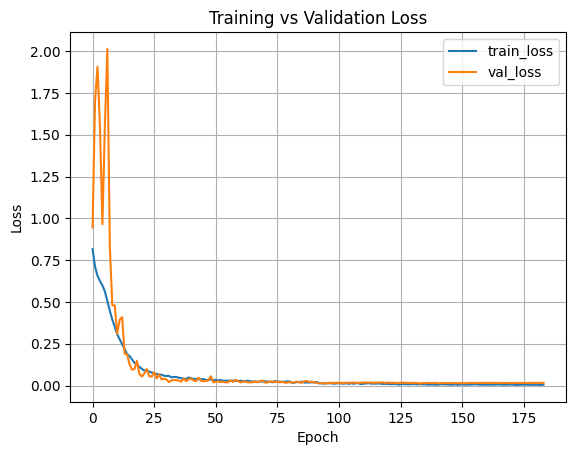

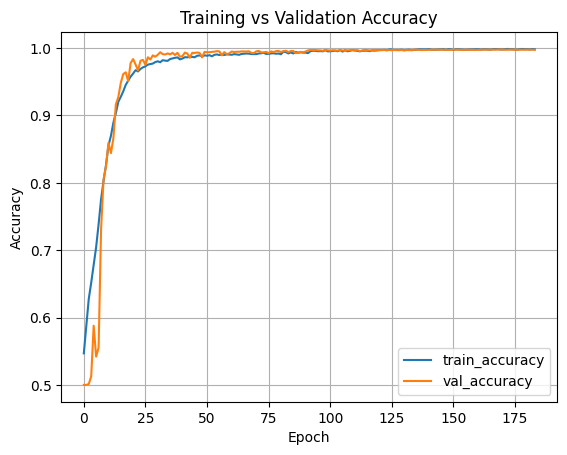


[STEP 10] Predicting test data...
68/68 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step


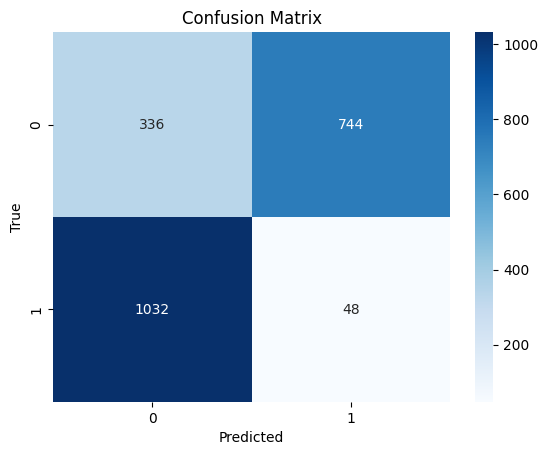

Confusion Matrix:
[[ 336  744]
 [1032   48]]
Accuracy: 0.1778
Precision: 0.0606
Recall/Sensitivity: 0.0444
Specificity: 0.3111
F1-Score: 0.0513


Cohen's Kappa: -0.6444
[STEP 10] Model saved as eegformer-final.h5


In [15]:
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import BinaryAccuracy

# %% Step 10 - Modeling, training, and evaluation using EEGFormer

print("\n[STEP 10] Splitting train/validation data...")

X_train, X_val, y_train, y_val = train_test_split(
    train_data_norm,
    selected_targets,
    test_size=0.2,
    random_state=42,
    stratify=selected_targets
)

print(f"[STEP 10] Training data shape: {X_train.shape}")
print(f"[STEP 10] Validation data shape: {X_val.shape}")
print(f"[STEP 10] y_train shape: {y_train.shape}")
print(f"[STEP 10] y_val shape: {y_val.shape}")


def get_lr(opt):
    try:
        return float(tf.keras.backend.get_value(opt.learning_rate))
    except Exception:
        try:
            return float(opt.learning_rate.numpy())
        except Exception:
            try:
                return float(opt.lr.numpy())
            except Exception:
                return float(getattr(opt, "lr", 0.0))


def _cap_kernel(k: int, S: int) -> int:
    return max(1, min(int(k), int(S)))


def _pick_safe_temporal_pools(S: int, preferred=(8, 4)):
    candidates = [
        preferred,
        (4, 4),
        (4, 3),
        (3, 3),
        (3, 2),
        (2, 2),
        (2, 1),
        (1, 1)
    ]

    for p1, p2 in candidates:
        if (S // p1) // p2 >= 1:
            return (1, p1), (1, p2)

    return (1, 1), (1, 1)


def SpatialAttention(x):
    attn = GlobalAveragePooling2D()(x)
    attn = Dense(64, activation="relu")(attn)

    M = K.int_shape(x)[1]

    if M is None:
        raise ValueError("Electrode dimension must be known")

    attn = Dense(M, activation="sigmoid")(attn)
    attn = Reshape((M, 1, 1))(attn)

    return Multiply()([x, attn])


def TransformerBlock(
    x,
    num_heads=4,
    key_dim=32,
    ff_dim=128,
    dropout_rate=0.1
):
    attn = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim
    )(x, x)

    attn = Dropout(dropout_rate)(attn)

    x = Add()([x, attn])
    x = LayerNormalization()(x)

    ff = Dense(ff_dim, activation="relu")(x)
    ff = Dropout(dropout_rate)(ff)
    ff = Dense(K.int_shape(x)[-1])(ff)

    x = Add()([x, ff])
    x = LayerNormalization()(x)

    return x


def EEGNet_SpatialTransformer(
    input_shape,
    dropout_rate=0.5,
    num_heads=4,
    ff_dim=128
):
    M, S, C = input_shape

    if C != 1:
        raise ValueError("Expected input_shape=(M, S, 1)")

    k1 = _cap_kernel(5, S)
    k2 = _cap_kernel(3, S)

    pool1, pool2 = _pick_safe_temporal_pools(S)

    inputs = Input(shape=input_shape)

    x = SeparableConv2D(
        32,
        (1, k1),
        padding="same",
        use_bias=False
    )(inputs)

    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = SpatialAttention(x)

    x = DepthwiseConv2D(
        (M, 1),
        depth_multiplier=2,
        padding="same",
        use_bias=False
    )(x)

    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    ch_out = K.int_shape(x)[-1]

    proj = Conv2D(
        ch_out,
        (1, 1),
        padding="same",
        use_bias=False
    )(inputs)

    proj = BatchNormalization()(proj)

    x = Add()([x, proj])
    x = BatchNormalization()(x)

    x = AveragePooling2D(pool1)(x)
    x = Dropout(dropout_rate)(x)

    x = SeparableConv2D(
        64,
        (1, k2),
        padding="same",
        use_bias=False
    )(x)

    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = AveragePooling2D(pool2)(x)
    x = Dropout(dropout_rate)(x)

    _, M_eff, S_eff, C_eff = K.int_shape(x)

    x = Reshape((M_eff, S_eff * C_eff))(x)

    x = TransformerBlock(
        x,
        num_heads=num_heads,
        ff_dim=ff_dim
    )

    x = GlobalAveragePooling1D()(x)
    x = BatchNormalization()(x)

    x = Dense(128, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)

    # Binary classification output
    outputs = Dense(1, activation="sigmoid")(x)

    model = Model(
        inputs=inputs,
        outputs=outputs,
        name="EEGNet_SpatialTransformer_refit"
    )

    return model


print("\n[STEP 10] Checking required variables...")

for name in ["X_train", "X_val", "y_train", "y_val", "test_data_norm", "y_test_cnn"]:
    assert name in globals(), f"[ERROR] Missing required variable: {name}"

print("[STEP 10] Required variables are available.")

n_electrodes = X_train.shape[1]
segment_size = X_train.shape[2]
input_shape = (n_electrodes, segment_size, 1)

print(f"[STEP 10] Model input shape: {input_shape}")

X_train = X_train.astype(np.float32, copy=False)
X_val = X_val.astype(np.float32, copy=False)

y_train = y_train.astype(np.float32, copy=False)
y_val = y_val.astype(np.float32, copy=False)

print("[STEP 10] Unique training labels:", np.unique(y_train))

print("\n[STEP 10] Building EEGFormer model...")

model = EEGNet_SpatialTransformer(
    input_shape=input_shape,
    dropout_rate=0.5,
    num_heads=4,
    ff_dim=128
)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=BinaryCrossentropy(),
    metrics=[BinaryAccuracy(name="accuracy", threshold=0.5)]
)

model.summary()

print("[STEP 10] Initial LR:", get_lr(model.optimizer))


lr_scheduler = ReduceLROnPlateau(
    monitor="loss",
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=50,
    restore_best_weights=True,
    verbose=1
)

ckpt = ModelCheckpoint(
    filepath="sub-71_eegformer_model.h5",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

csv_logger = CSVLogger(
    "eegformer_training_log.csv",
    append=False
)

callbacks = [lr_scheduler, early_stop, ckpt, csv_logger]


EPOCHS = 300
BATCH_SIZE = 200

print("\n[STEP 10] Starting EEGFormer training...")

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

print("[STEP 10] Training complete.")
print("[STEP 10] Best val_loss    :", float(np.min(history.history["val_loss"])))
print("[STEP 10] Best val_accuracy:", float(np.max(history.history["val_accuracy"])))
print("[STEP 10] Final LR         :", get_lr(model.optimizer))


print("\n[STEP 10] Evaluating on held-out test set...")

X_test_final = test_data_norm.astype(np.float32, copy=False)
y_test_final = y_test_cnn.astype(np.float32, copy=False)

test_loss, test_acc = model.evaluate(
    X_test_final,
    y_test_final,
    batch_size=BATCH_SIZE,
    verbose=1
)

print(f"[STEP 10] Test loss    : {test_loss:.4f}")
print(f"[STEP 10] Test accuracy: {test_acc:.4f}")


plt.figure()
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


plt.figure()
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


print("\n[STEP 10] Predicting test data...")

y_pred_probs = model.predict(X_test_final, verbose=1)

# Convert sigmoid probabilities to binary class labels
y_pred = (y_pred_probs >= 0.5).astype(int).reshape(-1)

y_test_final_int = y_test_final.astype(int).reshape(-1)

conf_matrix = confusion_matrix(y_test_final_int, y_pred)

sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print("Confusion Matrix:")
print(conf_matrix)


TN, FP = conf_matrix[0, 0], conf_matrix[0, 1]
FN, TP = conf_matrix[1, 0], conf_matrix[1, 1]

accuracy = (TP + TN) / (TP + TN + FP + FN)

precision = TP / (TP + FP) if (TP + FP) != 0 else 0

recall = TP / (TP + FN) if (TP + FN) != 0 else 0

specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

f1_score = (
    2 * (precision * recall) / (precision + recall)
    if (precision + recall) != 0
    else 0
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall/Sensitivity: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1_score:.4f}")

kappa = cohen_kappa_score(y_test_final_int, y_pred)
print(f"Cohen's Kappa: {kappa:.4f}")


# Save final model as H5 file
model.save("eegformer-final.h5")
print("[STEP 10] Model saved as eegformer-final.h5")

Step 11 – Gradient-Based Saliency

In [16]:
# %% Step 11 - Gradient-based saliency scores

print("\n[STEP 11] Starting gradient-based saliency computation...")


def compute_electrode_saliency(model, input_sample):
    input_sample = tf.convert_to_tensor(input_sample, dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(input_sample)
        prediction = model(input_sample, training=False)

    grads = tape.gradient(prediction, input_sample)
    grads = tf.abs(grads)

    saliency = tf.reduce_mean(grads, axis=(2, 3))

    return saliency.numpy().flatten()


all_saliencies = []

for i in tqdm(range(train_data_norm.shape[0]), desc="Computing Saliency"):
    sample = train_data_norm[i:i + 1]
    saliency = compute_electrode_saliency(model, sample)
    all_saliencies.append(saliency)

all_saliencies = np.array(all_saliencies, dtype=np.float32)

mean_saliency = np.mean(all_saliencies, axis=0)

normalized_saliency = mean_saliency / np.max(mean_saliency)

electrode_names = [
    "Fp1", "AF3", "AF7", "Fz", "F1", "F3", "F5", "F7", "FC1", "FC3", "FC5", "FT7",
    "Cz", "C1", "C3", "C5", "T7", "CP1", "CP3", "CP5", "TP7", "TP9", "Pz", "P1",
    "P3", "P5", "P7", "PO3", "PO7", "Oz", "O1", "Fpz", "Fp2", "AF4", "AF8", "F2",
    "F4", "F6", "F8", "FC2", "FC4", "FC6", "FT8", "C2", "C4", "C6", "T8", "CPz",
    "CP2", "CP4", "CP6", "TP8", "TP10", "P2", "P4", "P6", "P8", "POz", "PO4", "PO8", "O2"
]

if len(electrode_names) != len(normalized_saliency):
    raise RuntimeError(
        f"[STEP 11] Electrode name count {len(electrode_names)} does not match "
        f"saliency length {len(normalized_saliency)}."
    )

saliency_df = pd.DataFrame({
    "Electrode": electrode_names,
    "Saliency Score": normalized_saliency
})

saliency_df.to_csv("sub71_gradient_saliency_scores.csv", index=False)

print("[STEP 11] Saved gradient saliency scores to sub71_gradient_saliency_scores.csv")
print(saliency_df.head())


[STEP 11] Starting gradient-based saliency computation...


Computing Saliency: 100%|██████████| 28000/28000 [41:11<00:00, 11.33it/s]

[STEP 11] Saved gradient saliency scores to sub71_gradient_saliency_scores.csv
  Electrode  Saliency Score
0       Fp1        0.025946
1       AF3        0.076225
2       AF7        0.539379
3        Fz        0.762710
4        F1        0.006593


Step 12 – Brain Topographic Map


[STEP 12] Creating topographic map of electrode importance...


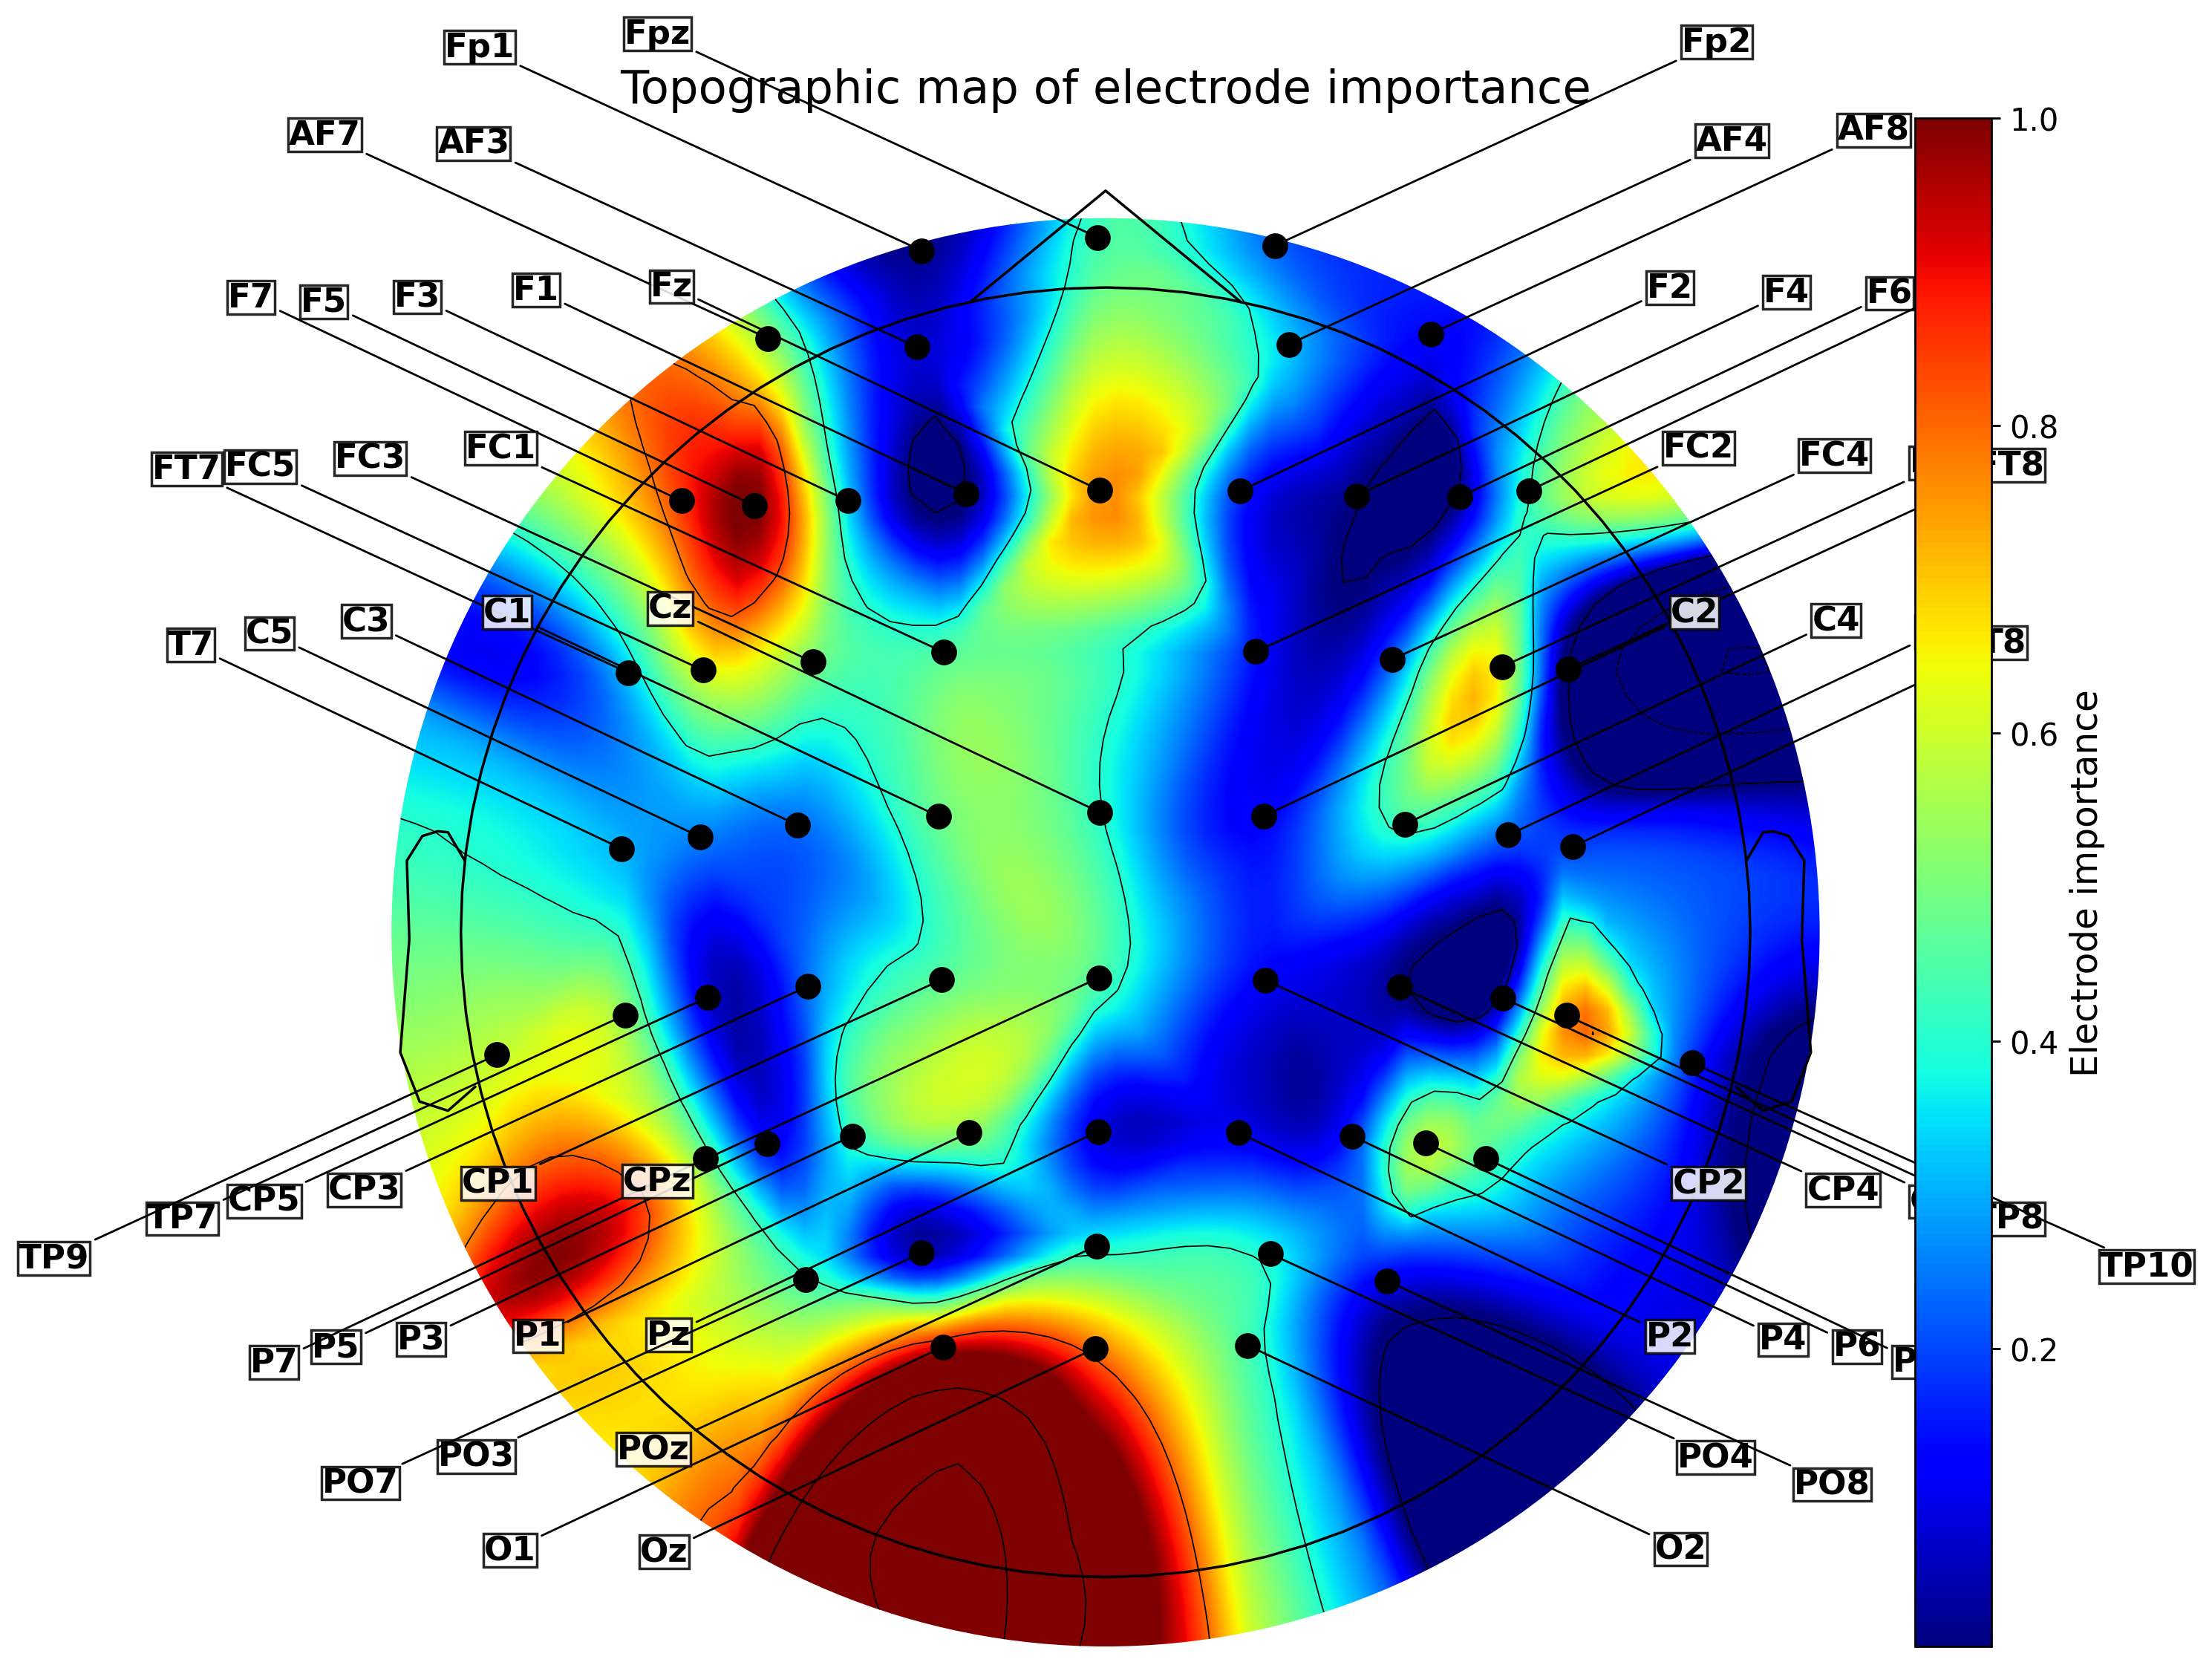

[STEP 12] Topographic map completed.


In [17]:
# %% Step 12 - Brain topographic map

print("\n[STEP 12] Creating topographic map of electrode importance...")

if "normalized_saliency" in globals() and "electrode_names" in globals():
    ch_names = list(electrode_names)
    values = np.asarray(normalized_saliency, dtype=float)
else:
    df = pd.read_csv("sub71_gradient_saliency_scores.csv")
    ch_names = df["Electrode"].astype(str).tolist()
    values = df["Saliency Score"].to_numpy(dtype=float)

info = mne.create_info(
    ch_names=ch_names,
    sfreq=500.0,
    ch_types="eeg"
)

montage = mne.channels.make_standard_montage("standard_1020")

info.set_montage(
    montage,
    match_case=False,
    on_missing="ignore"
)

good_idx = []

for i, ch in enumerate(info["chs"]):
    xyz = ch["loc"][:3]

    if np.any(xyz) and np.all(np.isfinite(xyz)):
        good_idx.append(i)

values_good = values[good_idx]

info_good = mne.pick_info(info, sel=good_idx)

names_good = info_good.ch_names

coords2d = mne.channels.layout._find_topomap_coords(
    info_good,
    picks=np.arange(len(names_good))
)

fig, ax = plt.subplots(figsize=(14, 9), dpi=250)

vmin, vmax = float(values_good.min()), float(values_good.max())

im, cn = mne.viz.plot_topomap(
    values_good,
    info_good,
    axes=ax,
    show=False,
    contours=6,
    sensors=False,
    outlines="head",
    vlim=(vmin, vmax),
    cmap="jet"
)

dot_size = 18
font_size = 13
arrow_lw = 0.8

for (x, y), name in zip(coords2d, names_good):

    ax.plot(x, y, "k.", markersize=dot_size, zorder=10)

    x_off = 0.06 if x >= 0 else -0.06
    y_off = 0.03 if y >= 0 else -0.03

    ax.annotate(
        name,
        xy=(x, y),
        xytext=(x + x_off, y + y_off),
        textcoords="data",
        fontsize=font_size,
        fontweight="bold",
        ha="left" if x >= 0 else "right",
        va="center",
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            alpha=0.85,
            pad=0.2
        ),
        arrowprops=dict(
            arrowstyle="-",
            color="black",
            lw=arrow_lw
        ),
        zorder=11
    )

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Electrode importance", fontsize=14)
cbar.ax.tick_params(labelsize=12)

ax.set_title(
    "Topographic map of electrode importance",
    fontsize=18
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

print("[STEP 12] Topographic map completed.")

Step 13 – Attention-Based Saliency Score

In [18]:
# %% Step 13 - Attention-based saliency score

print("\n[STEP 13] Starting attention-based saliency computation...")


def get_attention_output_from_unnamed_layer(model, input_sample):
    """
    Gets attention output from the spatial attention Dense layer using shape heuristics.
    """

    attention_output = None

    expected_electrodes = input_sample.shape[1]

    for layer in model.layers:

        if isinstance(layer, tf.keras.layers.Dense):

            try:
                output_shape = layer.output_shape
            except Exception:
                continue

            if output_shape[-1] == expected_electrodes:
                attention_model = tf.keras.Model(
                    inputs=model.input,
                    outputs=layer.output
                )

                attention_output = attention_model(input_sample)
                break

    if attention_output is None:
        raise ValueError(
            "[STEP 13] Could not locate attention layer automatically. "
            "Please name the spatial attention Dense layer if this error occurs."
        )

    return attention_output.numpy()


all_attention_scores = []

for i in tqdm(range(train_data_norm.shape[0]), desc="Computing Attention Saliency"):

    sample = train_data_norm[i:i + 1]

    attention = get_attention_output_from_unnamed_layer(model, sample)

    all_attention_scores.append(attention.flatten())

mean_attention = np.mean(np.array(all_attention_scores), axis=0)

electrode_names = [
    "Fp1", "AF3", "AF7", "Fz", "F1", "F3", "F5", "F7", "FC1", "FC3", "FC5", "FT7",
    "Cz", "C1", "C3", "C5", "T7", "CP1", "CP3", "CP5", "TP7", "TP9", "Pz", "P1",
    "P3", "P5", "P7", "PO3", "PO7", "Oz", "O1", "Fpz", "Fp2", "AF4", "AF8", "F2",
    "F4", "F6", "F8", "FC2", "FC4", "FC6", "FT8", "C2", "C4", "C6", "T8", "CPz",
    "CP2", "CP4", "CP6", "TP8", "TP10", "P2", "P4", "P6", "P8", "POz", "PO4", "PO8", "O2"
]

if len(electrode_names) != len(mean_attention):
    raise RuntimeError(
        f"[STEP 13] Electrode name count {len(electrode_names)} does not match "
        f"attention score length {len(mean_attention)}."
    )

df_attention = pd.DataFrame({
    "Electrode": electrode_names,
    "Saliency Score": mean_attention
})

df_attention.to_csv("sub71_attention_saliency_scores.csv", index=False)

print("[STEP 13] Saved attention saliency to sub71_attention_saliency_scores.csv")
print(df_attention.head())


[STEP 13] Starting attention-based saliency computation...


Computing Attention Saliency:   0%|          | 0/28000 [00:00<?, ?it/s]


ValueError: [STEP 13] Could not locate attention layer automatically. Please name the spatial attention Dense layer if this error occurs.